## Multiple Feature Gradient Descent for Linear Regression

$$\hat{y} = \vec{w} \cdot \vec{x} + b$$

Goal: Implement Multiple Feature Gradient Descent using Vectorization

In [35]:
import numpy as np
import pandas as pd

### Viewing The Data

In [36]:
# Local housing dataset (545 homes); predict price from several numeric features
homes = pd.read_csv("../../data/Housing.csv")

features = ["area", "bedrooms", "bathrooms", "stories", "parking"]
X = homes[features].to_numpy(dtype=float)   # feature matrix (n, 5)
y = homes["price"].to_numpy(dtype=float)    # target (price)

homes[features + ["price"]].head()


,area,bedrooms,bathrooms,stories,parking,price
0,7420,4,2,3,2,13300000
1,8960,4,4,4,3,12250000
2,9960,3,2,2,2,12250000
3,7500,4,2,2,3,12215000
4,7420,4,1,2,2,11410000


In [48]:
# standardize each feature so gradient descent stays stable, using z-score normalization
# axis=0 -> one mean/std PER FEATURE (length 5), broadcast across all 545 homes
X_mu    = X.mean(axis=0)
X_sigma = X.std(axis=0)
X = (X - X_mu) / X_sigma


### The cost function

We measure how bad the current line is with **mean squared error** (MSE) over the $n$ data points:

$$J(\vec{w}, b) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)^2$$


In [38]:
#x first for mse formula, bc dot product (x is 545 x 5), w is 5x1
def cost(w, b, x, y):
    n = len(x)
    return np.sum((np.dot(x,w) + b - y)**2/(2*n))

### The gradients

To know which direction minimizes cost, take the partial derivatives of $J$ with respect to each parameter. Let the error on point $i$ be $e_i = \hat{y}_i - y_i = (\vec{w} \cdot \vec{x}_i + b) - y_i$.

$$\nabla_{\vec{w}} J = \frac{1}{n} \sum_{i=1}^{n} e_i \, \vec{x}_i \qquad\qquad \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} e_i$$

In [39]:
# calculate gradient of W at i 
def gradW(w, b, x, y):
    n = len(x)
    return np.dot((np.dot(x, w) + b) - y, x) / n

# calculate gradient of b
def gradB(w, b, x, y):
    n = len(x)
    return np.sum((np.dot(x, w) + b - y))/n

**The training loop:**
1. Predict $\hat{y} = wx + b$ for all points.
2. Compute the errors $e = \hat{y} - y$.
3. Compute the two gradients.
4. Update $\vec{w}$ and $\vec{b}$.
5. Repeat for a fixed number of iterations (or until the cost stops decreasing).


In [40]:
# initialize vars
w = np.zeros(X.shape[1])
b = 0
alpha = 0.1


In [44]:
# Gradient Descent Algorithm w/ multiple features

def gradient_descent(w, b):
    cost_history = []
    wb_history = []
    prev_J = float('inf')
    tol = 1e-9

    converged = False
    i = 0
    while not converged: 
        tmp_w = w - alpha * gradW(w, b, X, y)
        tmp_b = b - alpha * gradB(w, b, X, y)
        w = tmp_w
        b = tmp_b

        J = cost(w, b, X, y)
        cost_history.append(J)          
        wb_history.append((w, b))       

        if abs(prev_J - J) < tol:
            converged = True
            print(f"converged at iter {i}")
        prev_J = J
        i += 1


    return cost_history, wb_history

cost_history, wb_history = gradient_descent(w, b)

converged at iter 258


### Predicted vs actual price

Run every home through the learned model, $\hat{y} = X\vec{w} + b$, and plot each predicted price against its true price.

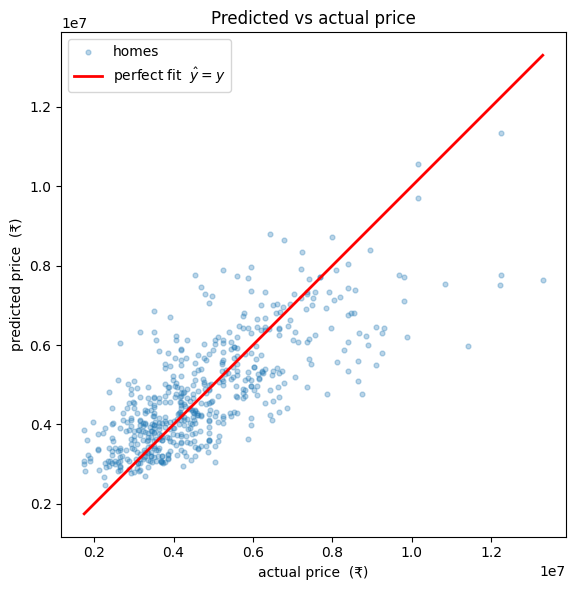

In [45]:
import matplotlib.pyplot as plt

# learned parameters from the last step of descent
w_opt, b_opt = wb_history[-1]

# predicted price for every home: y_hat = X w + b
y_pred = X @ w_opt + b_opt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, s=12, alpha=0.3, c="tab:blue", label="homes")

# red diagonal: where predicted == actual (a perfect model)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, c="red", lw=2, label=r"perfect fit  $\hat{y} = y$")

ax.set_xlabel("actual price  (₹)")
ax.set_ylabel("predicted price  (₹)")
ax.set_title("Predicted vs actual price")
ax.set_aspect("equal")
ax.legend()

plt.tight_layout()
plt.show()

### Cost vs iteration

Every step of gradient descent should lower the cost $J$. Plotting `cost_history` against iteration number shows the descent working: a steep early drop as the big gradients pull the weights toward the minimum, then a long flat tail as it fine-tunes and converges.

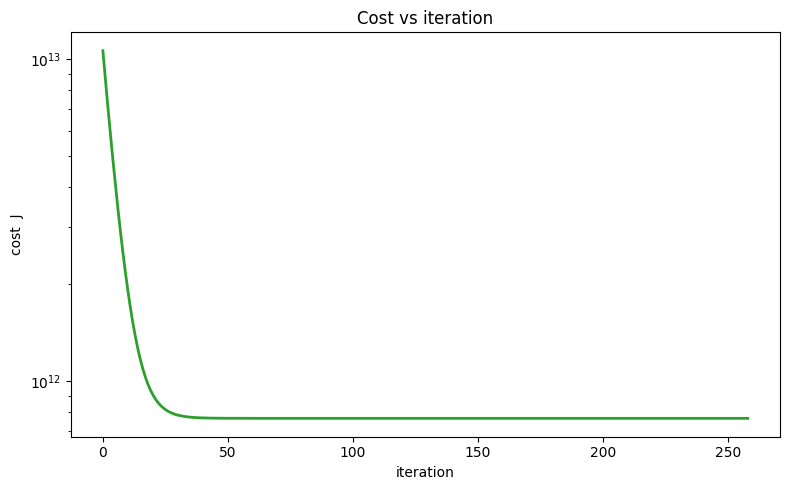

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_history, c="tab:green", lw=2)

ax.set_xlabel("iteration")
ax.set_ylabel("cost  J")
ax.set_title("Cost vs iteration")
ax.set_yscale("log")   # cost spans orders of magnitude; log makes the decay readable

plt.tight_layout()
plt.show()